# Bike Stores Sales Analysis
By: Mohamed Mahmoud

Database Link: https://www.sqlservertutorial.net/getting-started/sql-server-sample-database/

## Project Overview
The goal of this project is to clean, preprocess, and analyze the sales data from the **BikeStores** database. 
We will explore revenue trends, store performance, and product popularity to derive business insights.

## 1. Importing the Required Libraries and Connecting to SQL Server

In [1]:
import pyodbc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
conn = pyodbc.connect(
    'DRIVER={ODBC Driver 17 for SQL Server};'
    'SERVER=localhost;'
    'DATABASE=BikeStores;'
    'Trusted_Connection=yes;' 
)

In [3]:
# Connection Testing

cursor = conn.cursor()
cursor.execute("SELECT @@VERSION")
for row in cursor:
    print(row)

('Microsoft SQL Server 2025 (RTM) - 17.0.1000.7 (X64) \n\tOct 21 2025 12:05:57 \n\tCopyright (C) 2025 Microsoft Corporation\n\tStandard Developer Edition (64-bit) on Windows 10 Pro 10.0 <X64> (Build 26200: )\n',)


## 2. Fetching Data from the Database

In [4]:
query = """
        SELECT
            oi.order_id,
            oi.item_id,
            oi.product_id,
            oi.quantity,
            oi.list_price AS order_price,
            oi.discount,

            o.customer_id,
            o.order_status,
            o.order_date,
            o.required_date,
            o.shipped_date,
            o.store_id,
            o.staff_id,

            c.first_name AS customer_first_name,
            c.last_name AS customer_last_name,
            c.city AS customer_city,
            c.state AS customer_state,

            s.store_name,
            s.city AS store_city,
            s.state AS store_state,

            st.first_name AS staff_first_name,
            st.last_name AS staff_last_name
        FROM sales.order_items oi
        JOIN sales.orders o ON oi.order_id = o.order_id
        JOIN sales.customers c ON o.customer_id = c.customer_id
        JOIN sales.stores s ON o.store_id = s.store_id
        JOIN sales.staffs st ON o.staff_id = st.staff_id
        """

orders = pd.read_sql(query, conn)
orders.head()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_27220\2982611944.py:36: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  orders = pd.read_sql(query, conn)


,order_id,item_id,product_id,quantity,order_price,discount,customer_id,order_status,order_date,required_date,...,staff_id,customer_first_name,customer_last_name,customer_city,customer_state,store_name,store_city,store_state,staff_first_name,staff_last_name
0,1,1,20,1,599.99,0.20,259,4,2016-01-01,2016-01-03,...,2,Johnathan,Velazquez,Pleasanton,CA,Santa Cruz Bikes,Santa Cruz,CA,Mireya,Copeland
1,1,2,8,2,1799.99,0.07,259,4,2016-01-01,2016-01-03,...,2,Johnathan,Velazquez,Pleasanton,CA,Santa Cruz Bikes,Santa Cruz,CA,Mireya,Copeland
2,1,3,10,2,1549.00,0.05,259,4,2016-01-01,2016-01-03,...,2,Johnathan,Velazquez,Pleasanton,CA,Santa Cruz Bikes,Santa Cruz,CA,Mireya,Copeland
3,1,4,16,2,599.99,0.05,259,4,2016-01-01,2016-01-03,...,2,Johnathan,Velazquez,Pleasanton,CA,Santa Cruz Bikes,Santa Cruz,CA,Mireya,Copeland
4,1,5,4,1,2899.99,0.20,259,4,2016-01-01,2016-01-03,...,2,Johnathan,Velazquez,Pleasanton,CA,Santa Cruz Bikes,Santa Cruz,CA,Mireya,Copeland


In [5]:
query = """
        SELECT p.product_id, p.product_name, p.model_year, b.brand_name, c.category_name
        FROM production.products p
        JOIN production.brands b ON p.brand_id = b.brand_id
        JOIN production.categories c ON p.category_id = c.category_id
        """
products = pd.read_sql(query, conn)
products.head()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_27220\619754512.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  products = pd.read_sql(query, conn)


,product_id,product_name,model_year,brand_name,category_name
0,1,Trek 820 - 2016,2016,Trek,Mountain Bikes
1,2,Ritchey Timberwolf Frameset - 2016,2016,Ritchey,Mountain Bikes
2,3,Surly Wednesday Frameset - 2016,2016,Surly,Mountain Bikes
3,4,Trek Fuel EX 8 29 - 2016,2016,Trek,Mountain Bikes
4,5,Heller Shagamaw Frame - 2016,2016,Heller,Mountain Bikes


In [6]:
conn.close()

In [7]:
sales = orders.merge(products, on="product_id", how="left")

sales["revenue"] = (sales["quantity"] * sales["order_price"] * (1 - sales["discount"])).round(2)

## 3. Data Summarizing

In [8]:
sales.head()

,order_id,item_id,product_id,quantity,order_price,discount,customer_id,order_status,order_date,required_date,...,store_name,store_city,store_state,staff_first_name,staff_last_name,product_name,model_year,brand_name,category_name,revenue
0,1,1,20,1,599.99,0.20,259,4,2016-01-01,2016-01-03,...,Santa Cruz Bikes,Santa Cruz,CA,Mireya,Copeland,Electra Townie Original 7D EQ - Women's - 2016,2016,Electra,Cruisers Bicycles,479.99
1,1,2,8,2,1799.99,0.07,259,4,2016-01-01,2016-01-03,...,Santa Cruz Bikes,Santa Cruz,CA,Mireya,Copeland,Trek Remedy 29 Carbon Frameset - 2016,2016,Trek,Mountain Bikes,3347.98
2,1,3,10,2,1549.00,0.05,259,4,2016-01-01,2016-01-03,...,Santa Cruz Bikes,Santa Cruz,CA,Mireya,Copeland,Surly Straggler - 2016,2016,Surly,Cyclocross Bicycles,2943.10
3,1,4,16,2,599.99,0.05,259,4,2016-01-01,2016-01-03,...,Santa Cruz Bikes,Santa Cruz,CA,Mireya,Copeland,Electra Townie Original 7D EQ - 2016,2016,Electra,Cruisers Bicycles,1139.98
4,1,5,4,1,2899.99,0.20,259,4,2016-01-01,2016-01-03,...,Santa Cruz Bikes,Santa Cruz,CA,Mireya,Copeland,Trek Fuel EX 8 29 - 2016,2016,Trek,Mountain Bikes,2319.99


In [9]:
sales.columns

Index(['order_id', 'item_id', 'product_id', 'quantity', 'order_price',
       'discount', 'customer_id', 'order_status', 'order_date',
       'required_date', 'shipped_date', 'store_id', 'staff_id',
       'customer_first_name', 'customer_last_name', 'customer_city',
       'customer_state', 'store_name', 'store_city', 'store_state',
       'staff_first_name', 'staff_last_name', 'product_name', 'model_year',
       'brand_name', 'category_name', 'revenue'],
      dtype='object')

In [10]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4722 entries, 0 to 4721
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   order_id             4722 non-null   int64  
 1   item_id              4722 non-null   int64  
 2   product_id           4722 non-null   int64  
 3   quantity             4722 non-null   int64  
 4   order_price          4722 non-null   float64
 5   discount             4722 non-null   float64
 6   customer_id          4722 non-null   int64  
 7   order_status         4722 non-null   int64  
 8   order_date           4722 non-null   object 
 9   required_date        4722 non-null   object 
 10  shipped_date         4214 non-null   object 
 11  store_id             4722 non-null   int64  
 12  staff_id             4722 non-null   int64  
 13  customer_first_name  4722 non-null   object 
 14  customer_last_name   4722 non-null   object 
 15  customer_city        4722 non-null   o

In [11]:
sales.describe(include = 'all').round()

,order_id,item_id,product_id,quantity,order_price,discount,customer_id,order_status,order_date,required_date,...,store_name,store_city,store_state,staff_first_name,staff_last_name,product_name,model_year,brand_name,category_name,revenue
count,4722.0,4722.0,4722.0,4722.0,4722.0,4722.0,4722.0,4722.0,4722,4722,...,4722,4722,4722,4722,4722,4722,4722.0,4722,4722,4722.0
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,725,734,...,3,3,3,6,6,278,NaN,9,7,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-06,2018-04-06,...,Baldwin Bikes,Baldwin,NY,Marcelene,Boyer,Electra Townie Original 21D - 2016,NaN,Electra,Cruisers Bicycles,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27,27,...,3195,3195,3195,1615,1615,193,NaN,1729,1378,NaN
mean,821.0,2.0,59.0,1.0,1213.0,0.0,659.0,4.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2017.0,NaN,NaN,1628.0
std,465.0,1.0,67.0,1.0,1353.0,0.0,444.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,2018.0
min,1.0,1.0,2.0,1.0,90.0,0.0,1.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2016.0,NaN,NaN,72.0
25%,423.0,1.0,14.0,1.0,429.0,0.0,238.0,4.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2016.0,NaN,NaN,475.0
50%,828.0,2.0,28.0,1.0,600.0,0.0,646.0,4.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2017.0,NaN,NaN,846.0
75%,1226.0,3.0,84.0,2.0,1549.0,0.0,1052.0,4.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2017.0,NaN,NaN,1800.0


In [12]:
sales.shape

(4722, 27)

In [13]:
sales.isna().sum()

order_id                 0
item_id                  0
product_id               0
quantity                 0
order_price              0
discount                 0
customer_id              0
order_status             0
order_date               0
required_date            0
shipped_date           508
store_id                 0
staff_id                 0
customer_first_name      0
customer_last_name       0
customer_city            0
customer_state           0
store_name               0
store_city               0
store_state              0
staff_first_name         0
staff_last_name          0
product_name             0
model_year               0
brand_name               0
category_name            0
revenue                  0
dtype: int64

In [14]:
sales.duplicated().sum()

np.int64(0)

In [15]:
sales.dtypes

order_id                 int64
item_id                  int64
product_id               int64
quantity                 int64
order_price            float64
discount               float64
customer_id              int64
order_status             int64
order_date              object
required_date           object
shipped_date            object
store_id                 int64
staff_id                 int64
customer_first_name     object
customer_last_name      object
customer_city           object
customer_state          object
store_name              object
store_city              object
store_state             object
staff_first_name        object
staff_last_name         object
product_name            object
model_year               int64
brand_name              object
category_name           object
revenue                float64
dtype: object

## 4. Handling Outliers

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_27220\3685103327.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quantity', data=sales, palette='Purples')


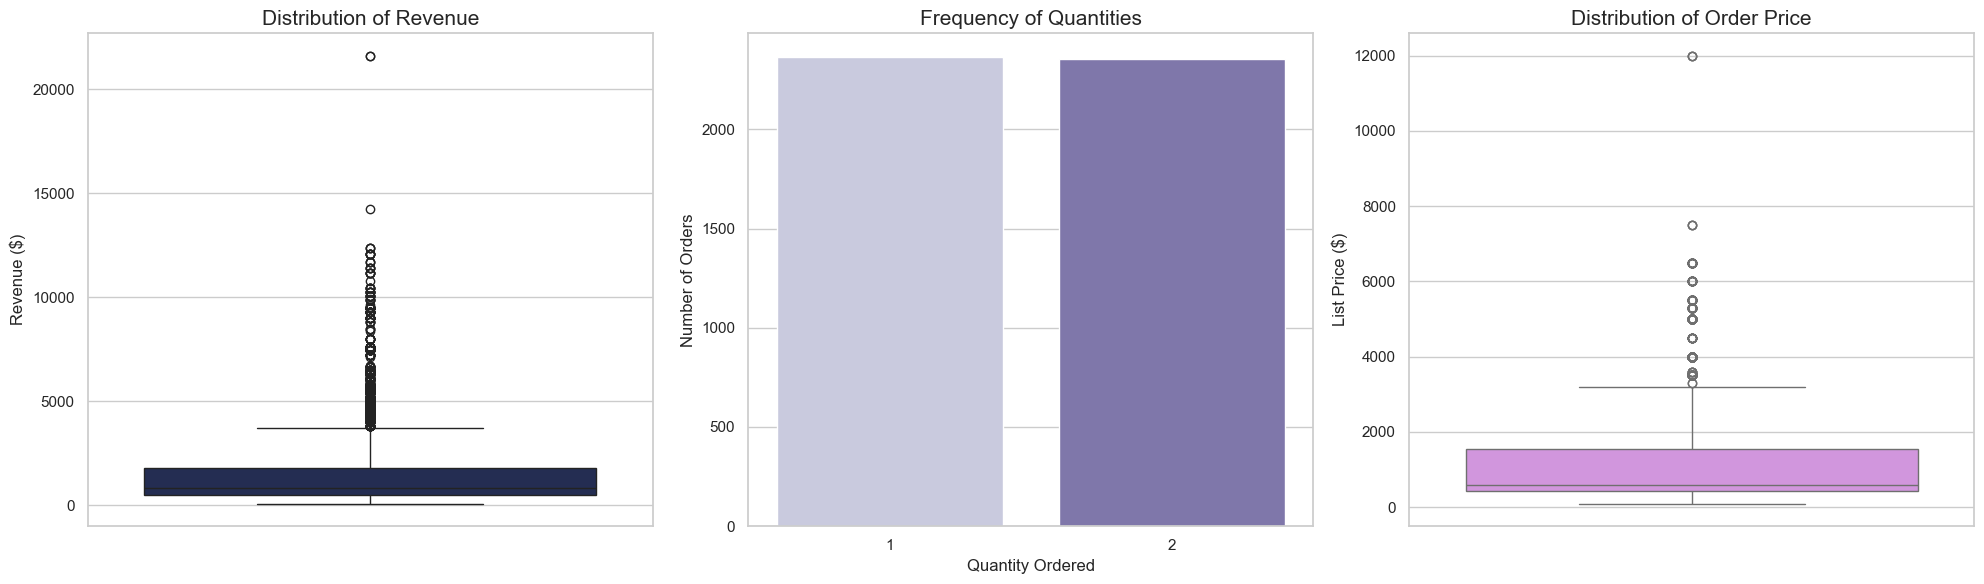

In [16]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(20, 6))

plt.subplot(1, 3, 1)
sns.boxplot(y=sales['revenue'], color='#1c285a')
plt.title('Distribution of Revenue', fontsize=15)
plt.ylabel('Revenue ($)')

plt.subplot(1, 3, 2)
sns.countplot(x='quantity', data=sales, palette='Purples')
plt.title('Frequency of Quantities', fontsize=15)
plt.xlabel('Quantity Ordered')
plt.ylabel('Number of Orders')

plt.subplot(1, 3, 3)
sns.boxplot(y=sales['order_price'], color='#d98ae9')
plt.title('Distribution of Order Price', fontsize=15)
plt.ylabel('List Price ($)')

plt.tight_layout()
plt.show()

In [17]:
Q1 = sales['revenue'].quantile(0.25)
Q3 = sales['revenue'].quantile(0.75)
IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR
outlier_count = sales[sales['revenue'] > upper_limit].shape[0]

outlier_count

536

## 5. Feature Engineering

In [18]:
date_columns = ['order_date', 'required_date', 'shipped_date']
for col in date_columns:
    sales[col] = pd.to_datetime(sales[col])

In [19]:
sales['customer_name'] = sales['customer_first_name'] + " " + sales['customer_last_name']
sales['staff_name'] = sales['staff_first_name'] + " " + sales['staff_last_name']

status_labels = {1: 'Pending', 2: 'Processing', 3: 'Rejected', 4: 'Completed'}
sales['order_status'] = sales['order_status'].map(status_labels)

In [20]:
columns = ['customer_id', 'staff_id', 'store_id', 'customer_first_name', 
                'customer_last_name', 'staff_first_name', 'staff_last_name']

sales = sales.drop(columns=columns)

In [21]:
sales_cancelled = sales[sales['order_status'] == 'Rejected'].copy()

sales_completed = sales[sales['order_status'] == 'Completed'].copy()

## 6. Analysis

We need to answer the following questions:
1. What are the monthly and yearly revenue trends?
2. Which stores have the highest revenues?
3. Are some stores underperforming?
4. Which store has the highest rejection rate?
5. Which month has the highest count of cancelled orders?
6. What are the top selling products?
7. Which products generate the most revenue?
8. Which categories generate the most revenue?
9. Who are the most valuable customers?
10. Which cities have the most orders?

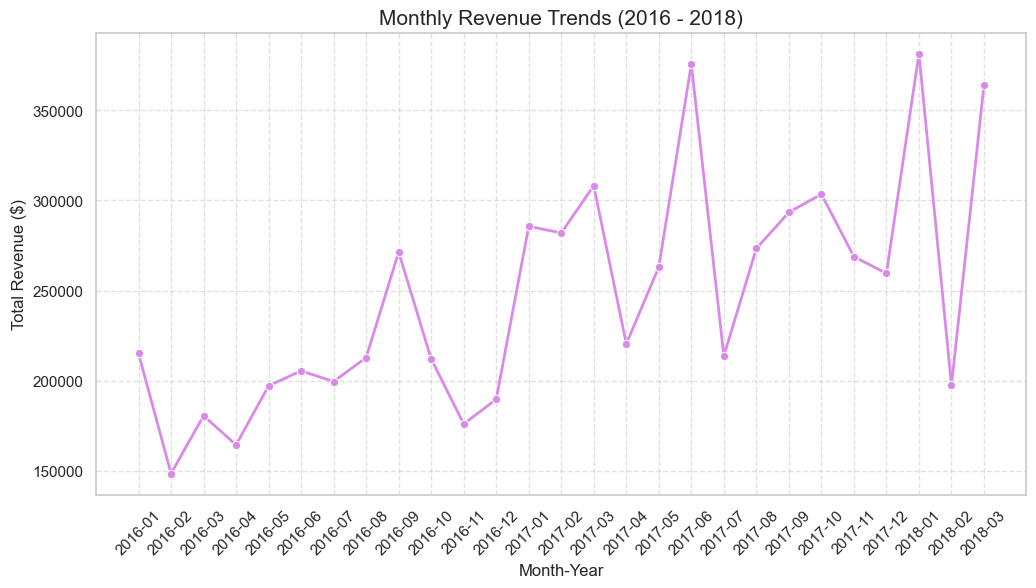

The peak sales month was 2018-01 with a total revenue of $381,429.86


In [32]:
# What are the monthly and yearly revenue trends?

sales_completed['YearMonth'] = sales_completed['order_date'].dt.to_period('M').astype(str)
monthly_revenue = sales_completed.groupby('YearMonth')['revenue'].sum()

plt.figure(figsize=(12, 6))
sns.lineplot(x=monthly_revenue.index, y=monthly_revenue.values, marker='o', color='#d98ae9', linewidth=2)
plt.xticks(rotation=45)
plt.title('Monthly Revenue Trends (2016 - 2018)', fontsize=15)
plt.xlabel('Month-Year', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

peak_month = monthly_revenue.idxmax()
peak_value = monthly_revenue.max()
print(f"The peak sales month was {peak_month} with a total revenue of ${peak_value:,.2f}")

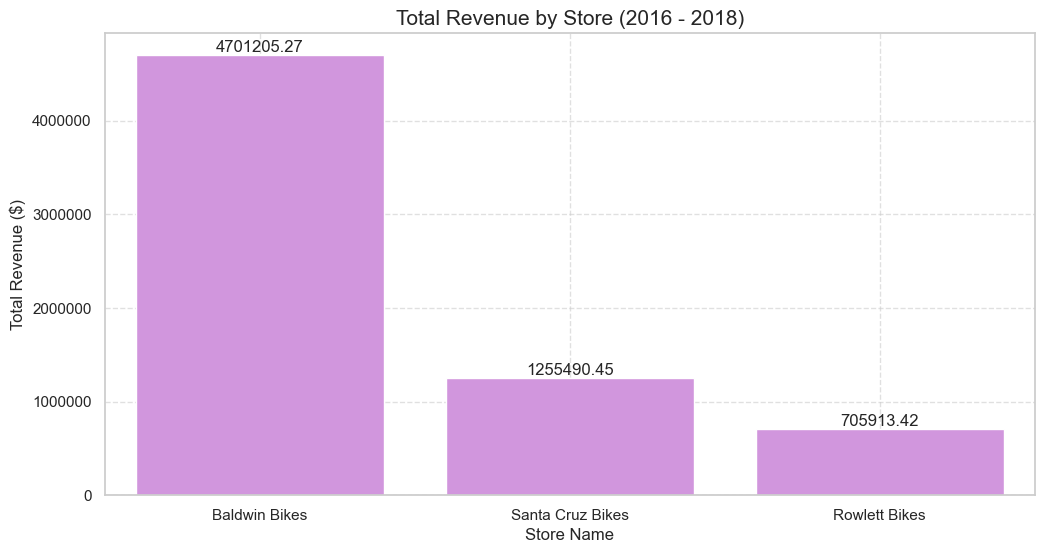

In [36]:
# 2. Which stores have the highest revenues?

store_revenues = sales_completed.groupby('store_name')['revenue'].sum().round(2).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x=store_revenues.index,
    y=store_revenues.values,
    color='#d98ae9'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')
    
plt.title('Total Revenue by Store (2016 - 2018)', fontsize=15)
plt.xlabel('Store Name', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.ticklabel_format(style='plain', axis='y')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

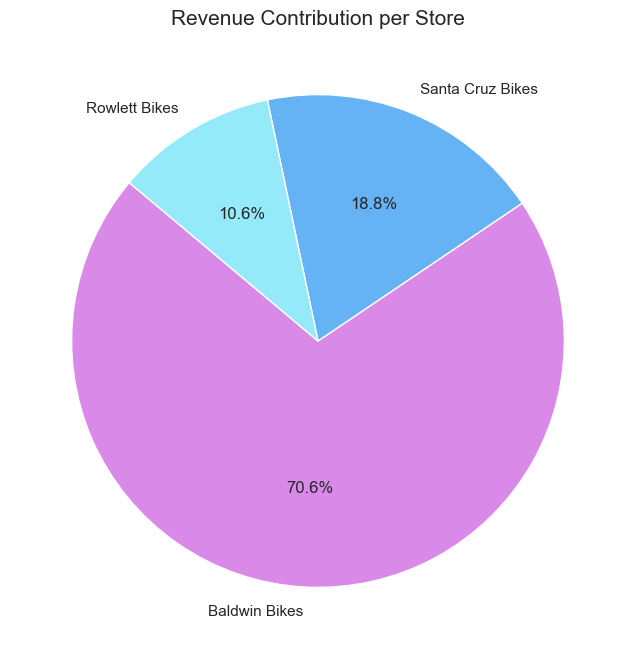

In [37]:
# 3. Are some stores underperforming?

total_revenue = store_revenues.sum()
store_percentage = (store_revenues / total_revenue) * 100


plt.figure(figsize=(8, 8))
plt.pie(store_percentage, labels=store_percentage.index, autopct='%1.1f%%', 
        colors=["#d98ae9","#65b2f5","#94eaf8"], startangle=140)
plt.title('Revenue Contribution per Store', fontsize=15)
plt.show()

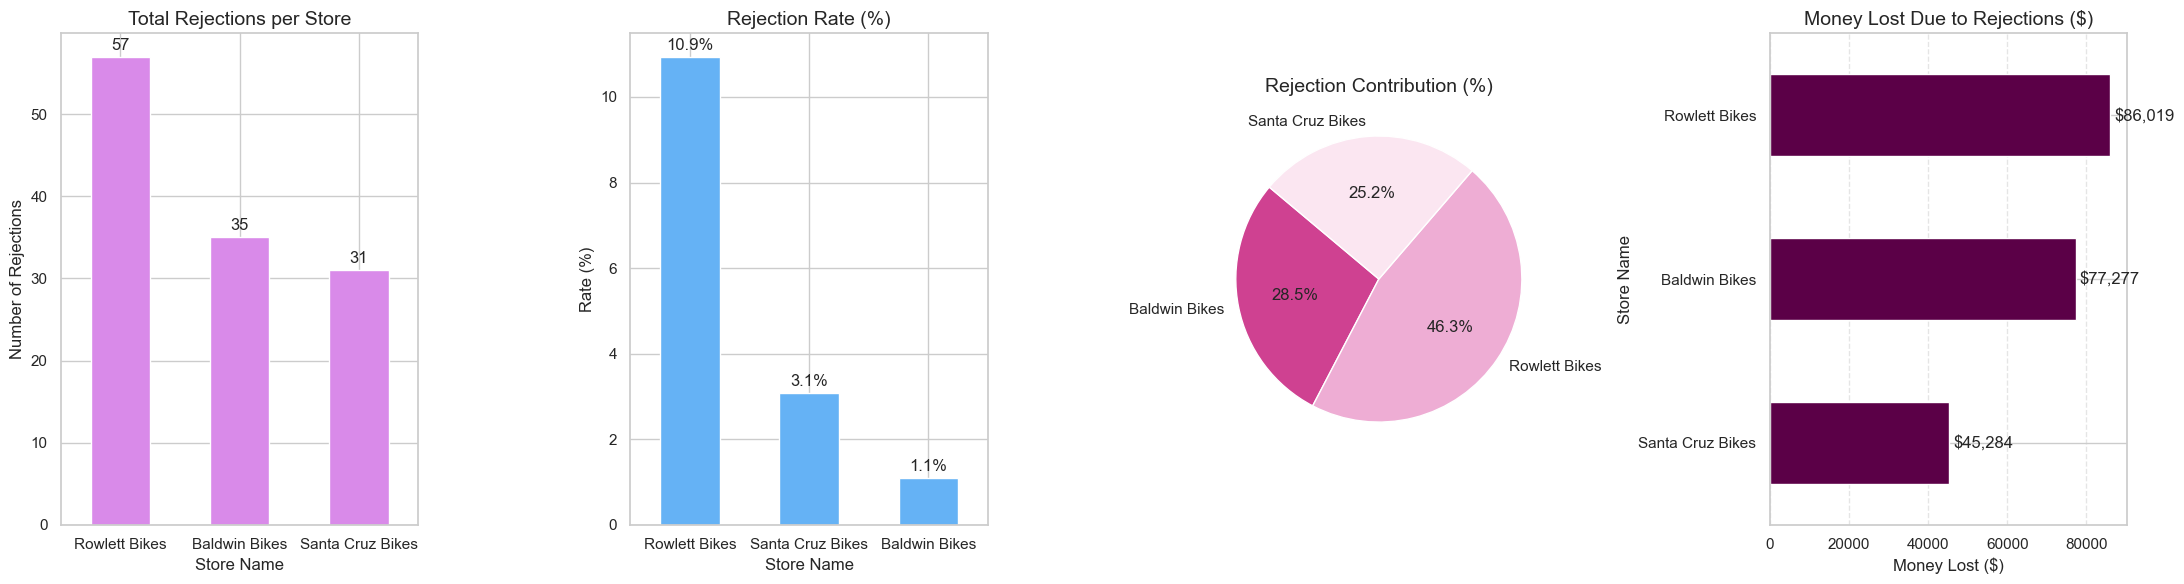

In [46]:
# 4. Which store has the highest rejection rate?

total_order_count = sales.groupby('store_name')['order_id'].count()
rejected_order_count = sales_cancelled.groupby('store_name')['order_id'].count()
total_rejected = rejected_order_count.sum()

rejection_rate = ((rejected_order_count / total_order_count) * 100).round(2)
rejection_rate_contribution = ((rejected_order_count / total_rejected) * 100).round(2)

total_loss = sales_cancelled.groupby('store_name')['revenue'].sum().sort_values(ascending=False).round(2)

plt.figure(figsize=(22, 6))

ax1 = plt.subplot(1, 4, 1)
rejected_order_count.sort_values(ascending=False).plot(
    kind='bar',
    color='#d98ae9',
    ax=ax1
)
for container in ax1.containers:
    ax1.bar_label(container, fmt='%d', padding=3)
ax1.set_title('Total Rejections per Store', fontsize=14)
ax1.set_ylabel('Number of Rejections')
ax1.set_xlabel('Store Name')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)


ax2 = plt.subplot(1, 4, 2)
rejection_rate.sort_values(ascending=False).plot(
    kind='bar',
    color='#65b2f5',
    ax=ax2
)
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.1f%%', padding=3)
ax2.set_title('Rejection Rate (%)', fontsize=14)
ax2.set_ylabel('Rate (%)')
ax2.set_xlabel('Store Name')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)

ax3 = plt.subplot(1, 4, 3)
rejection_rate_contribution.plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=sns.color_palette('PiYG'),
    startangle=140,
    ax=ax3
)
ax3.set_title('Rejection Contribution (%)', fontsize=14)
ax3.set_ylabel('')

ax4 = plt.subplot(1, 4, 4)
total_loss.sort_values(ascending=True).plot(
    kind='barh',
    color="#5b0047",
    ax=ax4
)
for container in ax4.containers:
    ax4.bar_label(
        container,
        labels=[f'${v:,.0f}' for v in total_loss.sort_values(ascending=True)],
        padding=3
    )
ax4.set_title('Money Lost Due to Rejections ($)', fontsize=14)
ax4.set_xlabel('Money Lost ($)')
ax4.set_ylabel('Store Name')
ax4.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

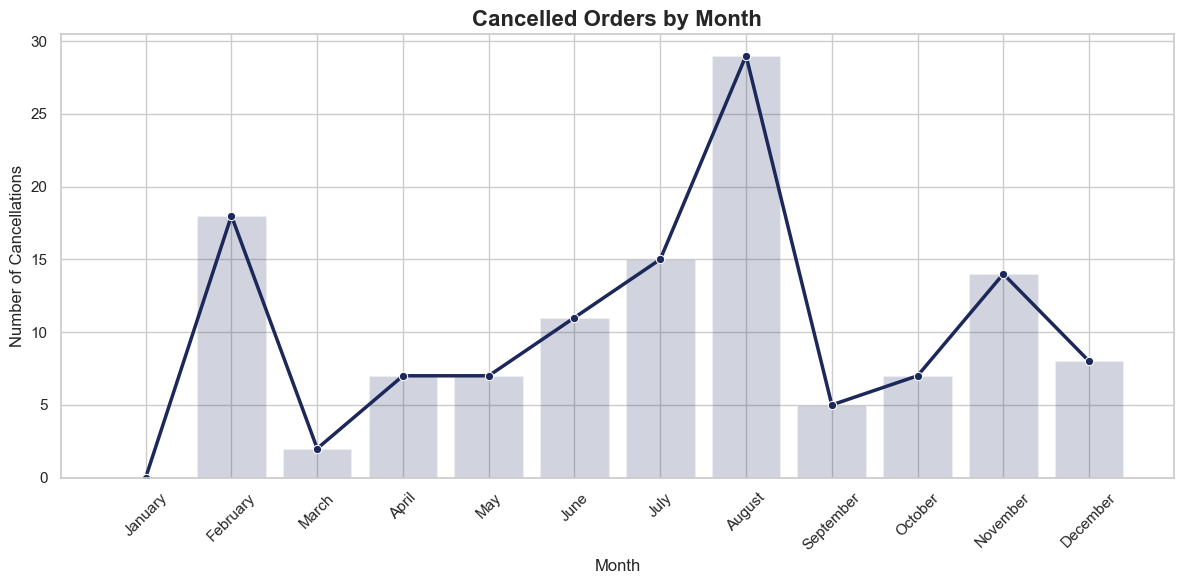

<bound method Series.sort_values of month
January       0.0
February     18.0
March         2.0
April         7.0
May           7.0
June         11.0
July         15.0
August       29.0
September     5.0
October       7.0
November     14.0
December      8.0
Name: order_id, dtype: float64>

In [49]:
# 5. Which month has the highest count of cancelled orders?

sales_cancelled['month'] = sales_cancelled['order_date'].dt.month_name()

monthly_cancelled = sales_cancelled.groupby('month')['order_id'].count()

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_cancelled = monthly_cancelled.reindex(month_order).fillna(0)

plt.figure(figsize=(12, 6))
sns.lineplot(x=monthly_cancelled.index, y=monthly_cancelled.values, marker='o', color='#1c285a', linewidth=2.5)
plt.bar(monthly_cancelled.index, monthly_cancelled.values, color='#1c285a', alpha=0.2)

plt.title('Cancelled Orders by Month', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Cancellations', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

monthly_cancelled.sort_values

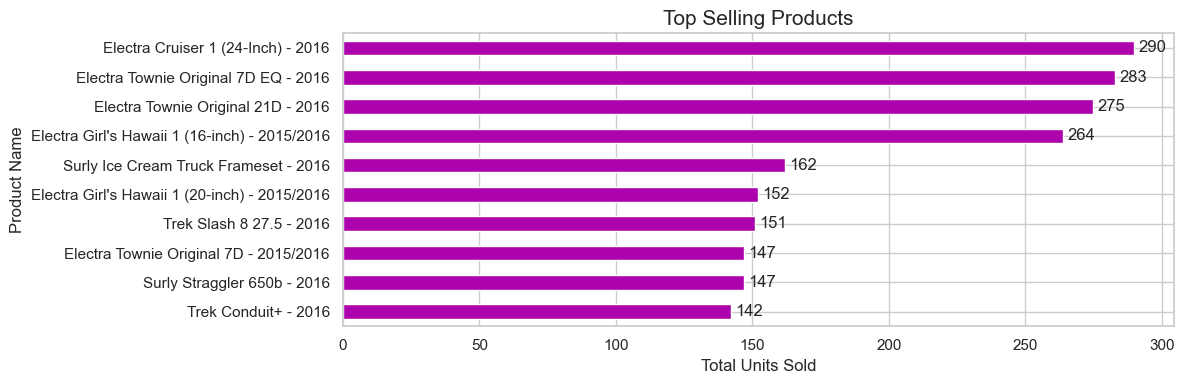

In [52]:
# 6. What are the top selling products?

top_qty = sales_completed.groupby('product_name')['quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 4))
ax = top_qty.plot(kind='barh', color="#AD03AD")
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)
ax.invert_yaxis()
plt.title('Top Selling Products', fontsize=15)
plt.xlabel('Total Units Sold')
plt.ylabel('Product Name')
plt.tight_layout()
plt.show()

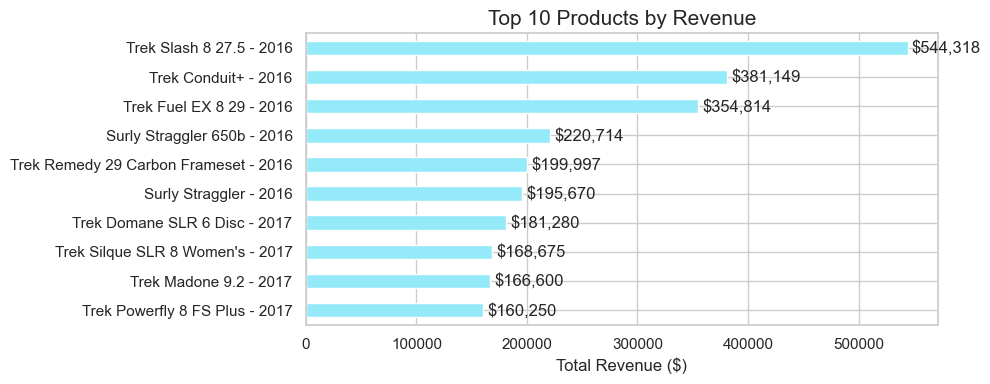

In [56]:
# 7. Which products generate the most revenue?

top_revenue = sales_completed.groupby('product_name')['revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 4))
ax = top_revenue.plot(kind='barh', color='#94eaf8')
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.0f}' for v in top_revenue],
        padding=3
    )
ax.invert_yaxis()
plt.title('Top 10 Products by Revenue', fontsize=15)
plt.xlabel('Total Revenue ($)')
plt.ylabel('')
plt.tight_layout()
plt.show()

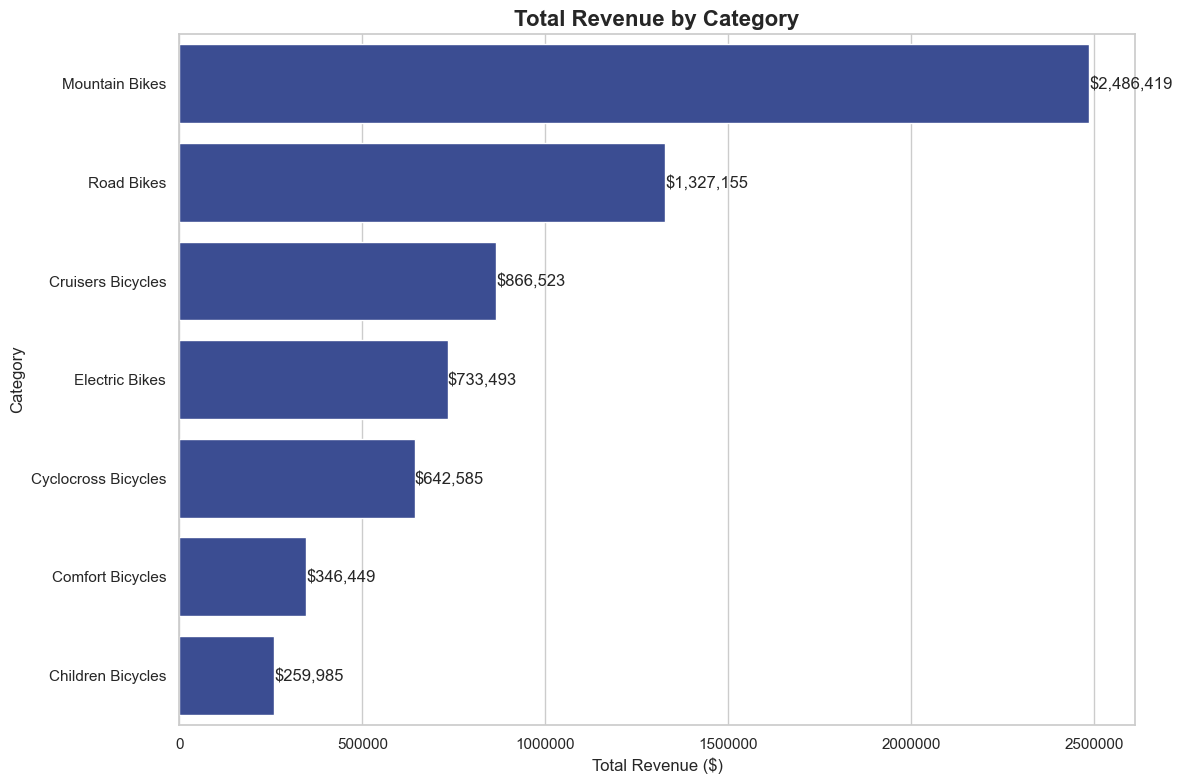

In [60]:
# 8. Which categories generate the most revenue?

category_revenue = sales_completed.groupby('category_name')['revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
ax = sns.barplot(
    x=category_revenue.values,
    y=category_revenue.index,
    color='#2D44A0'
)
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'${v:,.0f}' for v in category_revenue.values],
        padding=0
    )
plt.title('Total Revenue by Category', fontsize=16, fontweight='bold')
plt.xlabel('Total Revenue ($)', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.show()

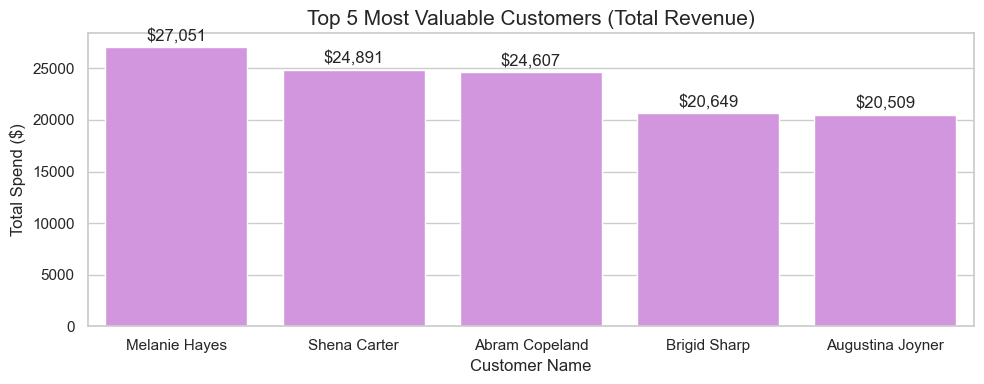

In [75]:
# 9. Who are the most valuable customers?

top_customers = sales_completed.groupby('customer_name')['revenue'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(10, 4))
ax = sns.barplot(
    x=top_customers.index,   
    y=top_customers.values,  
    color='#d98ae9'
)
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"${v:,.0f}" for v in container.datavalues],
        padding=3
    )
plt.title('Top 5 Most Valuable Customers (Total Revenue)', fontsize=15)
plt.xlabel('Customer Name')
plt.ylabel('Total Spend ($)')  
plt.tight_layout()
plt.show()


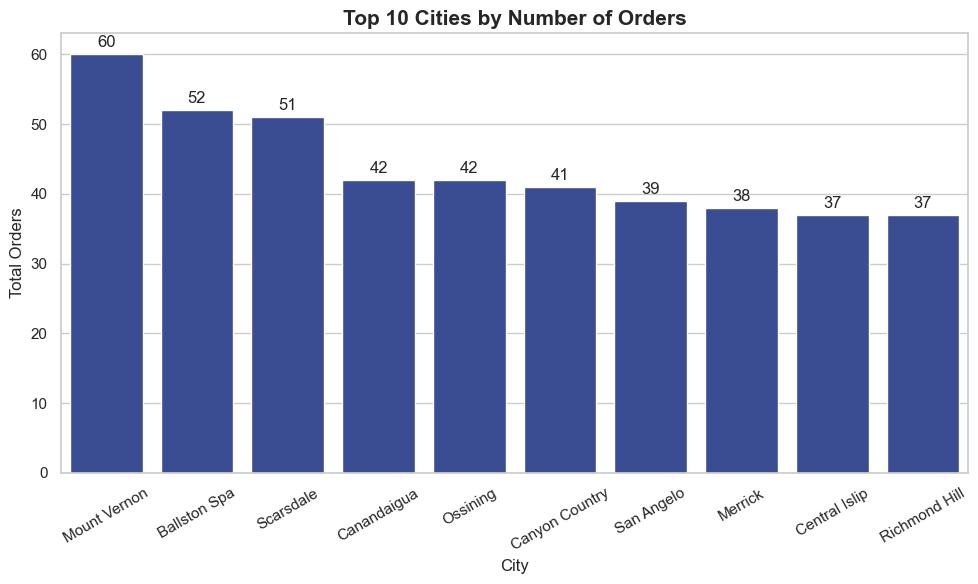

In [81]:
# 10. Which cities have the most orders?

top_cities = sales_completed.groupby('customer_city')['order_id'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=top_cities.index,   
    y=top_cities.values,  
    color='#2D44A0'
)
plt.title('Top 10 Cities by Number of Orders', fontsize=15, fontweight='bold')
plt.xlabel('City')
plt.ylabel('Total Orders')
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{v:,.0f}" for v in container.datavalues],
        padding=3
    )

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()